In [1]:
%matplotlib inline

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import os

# Chargement des tweets nettoyés
df = pd.read_csv("../data/gold/tweets_classified_clean_1.csv")
texts = df["clean_text"].dropna().tolist()

/Users/eliot/Desktop/projet_rncp/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import pandas as pd

# 1. Embedding
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

# 2. Clustering
kmeans = KMeans(n_clusters=6)
df["cluster"] = kmeans.fit_predict(embeddings)


Batches: 100%|██████████| 95/95 [01:07<00:00,  1.41it/s]


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


/Users/eliot/Desktop/projet_rncp/venv/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [6]:
import pandas as pd
import numpy as np
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans

# 1️⃣ Embedding des textes
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["clean_text"].tolist(), show_progress_bar=True)

# 2️⃣ (Optionnel) recalcul du meilleur k pour le clustering
best_k = 6  # ou choisis ton meilleur k après test silhouette
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df["cluster"] = kmeans.fit_predict(embeddings)

# 3️⃣ Score de silhouette global
silhouette = silhouette_score(embeddings, df["cluster"])
print(f"🌟 Silhouette globale = {silhouette:.4f}")

# 4️⃣ Analyse de correspondance entre cluster et colonnes métier
def analyze_alignment(df, col_label):
    """Mesure la cohérence entre les clusters et une étiquette connue"""
    valid = df.dropna(subset=[col_label])
    ari = adjusted_rand_score(valid[col_label], valid["cluster"])
    nmi = normalized_mutual_info_score(valid[col_label], valid["cluster"])
    print(f"\n🔍 Alignement cluster ↔ {col_label}")
    print(f"ARI  (Adjusted Rand Index): {ari:.4f}")
    print(f"NMI  (Normalized Mutual Info): {nmi:.4f}")

    # Tableau de croisement
    cross = pd.crosstab(valid["cluster"], valid[col_label], normalize="index") * 100
    print("\nDistribution (%) des labels par cluster :")
    print(cross.round(1))
    return cross

# 5️⃣ Applique sur label / domaine / sous_domaine
cross_label = analyze_alignment(df, "label")
cross_dom = analyze_alignment(df, "domaine")
cross_sub = analyze_alignment(df, "sous_domaine")


Batches: 100%|██████████| 95/95 [01:04<00:00,  1.47it/s]


🌟 Silhouette globale = 0.0421

🔍 Alignement cluster ↔ label
ARI  (Adjusted Rand Index): -0.0069
NMI  (Normalized Mutual Info): 0.0118

Distribution (%) des labels par cluster :
label    inconnu  problème avéré  problème non avéré
cluster                                             
0            5.5            90.5                 4.0
1           11.8            73.2                15.0
2            9.6            80.6                 9.8
3            6.2            82.1                11.6
4            6.2            82.0                11.7
5            9.4            76.3                14.3

🔍 Alignement cluster ↔ domaine
ARI  (Adjusted Rand Index): 0.0013
NMI  (Normalized Mutual Info): 0.0429

Distribution (%) des labels par cluster :
domaine  aucun  facture  fixe  inconnu  mobile
cluster                                       
0          4.0      5.3  65.9     15.7     9.1
1         15.5     12.1  47.0     15.2    10.3
2         10.5     24.9  46.1     11.8     6.8
3         11.9  

In [11]:
import pandas as pd

# Croisement normalisé par cluster
cross_label = pd.crosstab(df["cluster"], df["label"], normalize="index")

# Proportions globales dans tout le dataset
global_props = df["label"].value_counts(normalize=True).sort_index()

# Ratio = proportion du cluster / proportion globale
ratio = cross_label.div(global_props, axis=1)

print("Ratio (cluster vs proportion globale) :")
print(ratio.round(2))


Ratio (cluster vs proportion globale) :
label    inconnu  problème avéré  problème non avéré
cluster                                             
0           0.64            1.13                0.36
1           1.39            0.91                1.33
2           1.12            1.00                0.88
3           0.73            1.02                1.03
4           0.73            1.02                1.04
5           1.10            0.95                1.27


/var/folders/n3/b6s97z4x76z5q00jtt3w4w8m0000gn/T/ipykernel_57306/3752337717.py:14: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eliot/Desktop/projet_rncp/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


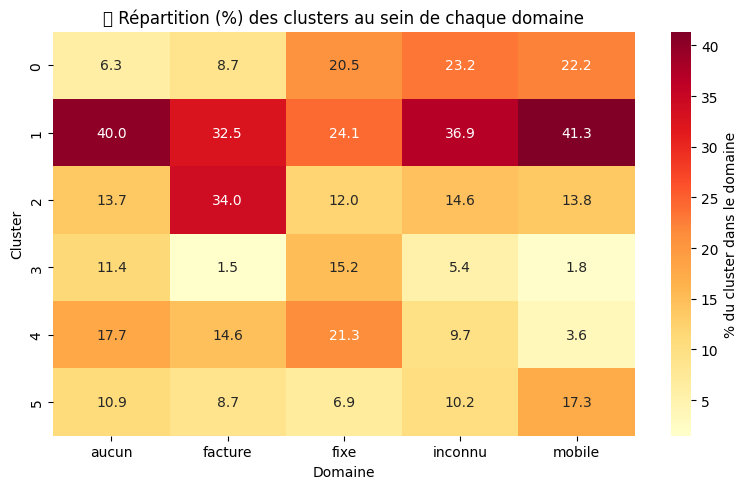

In [15]:
cross_domaine_col = pd.crosstab(df["cluster"], df["domaine"], normalize="columns") * 100

plt.figure(figsize=(8, 5))
sns.heatmap(
    cross_domaine_col,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    cbar_kws={'label': '% du cluster dans le domaine'}
)
plt.title("📊 Répartition (%) des clusters au sein de chaque domaine")
plt.xlabel("Domaine")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


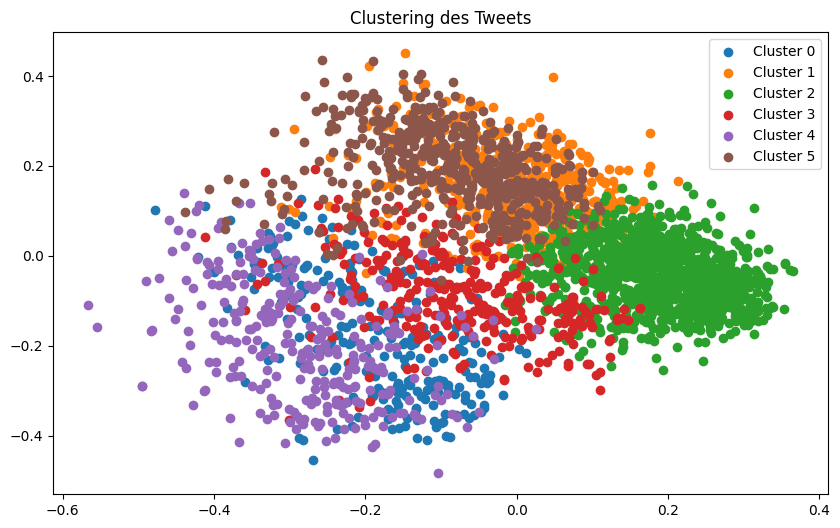

In [53]:
# Visualisation
pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings)
df["x"] = coords[:,0]
df["y"] = coords[:,1]

plt.figure(figsize=(10,6))
for i in range(k):
    subset = df[df["cluster"] == i]
    plt.scatter(subset["x"], subset["y"], label=f"Cluster {i}")
plt.legend()
plt.title("Clustering des Tweets")
plt.show()


In [54]:
for i in df["cluster"].unique():
    print(f"\n📌 Cluster {i} :")
    display(df[df["cluster"] == i]["clean_text"].sample(5, random_state=42))


📌 Cluster 1 :


1673    mon courrier a fait réagir cest biennpar contr...
457     cest sérieux votre service client qui réponds pas
1816    allô et pas dinternet depuis ce matin votre bo...
952     oui mais jai appeler pour avoir des infos etc ...
636     vous êtes des escrocs incompétents free demand...
Name: clean_text, dtype: object


📌 Cluster 3 :


759     après des années de foutage de gueule chez ora...
1120    je suis surpris dapprendre que je dois 50 euro...
2756    bon cela fait 1 moi que je suis dans mon appar...
1100    jai entamé le déménagement de ma fibre il y a ...
2573    toujours en attente depuis trois mois de la ré...
Name: clean_text, dtype: object


📌 Cluster 2 :


...

2795    cest normal il débranche les autres abonnés de...
522     ça ne vous dérange pas dannuler le rdv avec vo...
2063    jai voulu prendre lultra pour le wifi 7 je reg...
576     remettez la wifi pitié je suis au chapitre 6 d...
2667    bon on en est au 3eme jour de panne la on fait...
Name: clean_text, dtype: object


📌 Cluster 4 :


2792    bonjour sur la freebox pop player de mon père ...
1538    voilà une fois de plus en plein film plus de r...
812     bonjour freebox votre répéteur wi fi coute 20 ...
800     je viens de souscrire à une offre freebox en r...
2700    ouais enfin pendant ce temps jattends toujours...
Name: clean_text, dtype: object


📌 Cluster 0 :


400     même sans bras et sans jambes il serait plus r...
2270    laisser galérer ses clients pendant un déménag...
2647    réparée ma box svp ça fait 1 semaine elle wi f...
2340    ya pas à avoir une box qui se deco toute les 5...
2589    bon cest possible davoir internet nan parce qu...
Name: clean_text, dtype: object

In [ ]:
def analyze_()

,id,created_at,screen_name,full_text,clean_text,label,domaine,sous_domaine,model,status_code,request_time,duration_seconds,quality_flags,cleaned_at,prompt,cluster
2,1694675653205860558,2023-08-24 13:38:55 +02:00,jnbarrot,Dans la lutte contre les installations sauvage...,dans la lutte contre les installations sauvage...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 19:22:25,7.410,NaN,2025-10-29 19:06:07,dans la lutte contre les installations sauvage...,3
4,1709659172361404776,2023-10-04 21:58:05 +02:00,EllaVerite,"Bonsoir @WavemakerFR, je suis chez @free et vo...",bonsoir je suis chez et voici ma bande passant...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 19:22:37,6.563,NaN,2025-10-29 19:06:07,bonsoir je suis chez et voici ma bande passant...,1
6,1759266279620247842,2024-02-18 18:19:01 +01:00,TomReynaud1789,.@free a 25 ans et tient toujours ses promesse...,a 25 ans et tient toujours ses promesses en te...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 19:22:49,1.894,NaN,2025-10-29 19:06:07,a 25 ans et tient toujours ses promesses en te...,2
10,1813101958900879811,2024-07-16 08:42:47 +02:00,GrandOeil_,On ne se rend pas assez compte que sans Xavier...,on ne se rend pas assez compte que sans xavier...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 19:23:04,2.874,NaN,2025-10-29 19:06:07,on ne se rend pas assez compte que sans xavier...,0
20,1813628840624943206,2024-07-17 19:36:25 +02:00,gurbain69,@OQEEbyFree @wdufour105 @ultrakfr @Freebox Bon...,bonjourncomptez vous intégrer les versions hdr...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 19:23:47,6.053,NaN,2025-10-29 19:06:07,bonjourncomptez vous intégrer les versions hdr...,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2987,1931678641689108493,2025-06-08 13:44:11 +02:00,zoneadsl_panne,Si vous avez une #freebox et que vous vivez en...,si vous avez une et que vous vivez en ca va et...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 23:24:03,10.658,NaN,2025-10-29 19:06:07,si vous avez une et que vous vivez en ca va et...,1
2999,1932005295338754110,2025-06-09 11:22:11 +02:00,gwdad_moi,@Freebox @free c’est possible d’ajouter la sau...,cest possible dajouter la sauvegarde en arrièr...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 23:24:47,3.114,NaN,2025-10-29 19:06:07,cest possible dajouter la sauvegarde en arrièr...,1
3000,1932146022135848979,2025-06-09 20:41:23 +02:00,SalahBahra25701,"@free Bonjour, est ce que l'offre pops inclut ...",bonjour est ce que loffre pops inclut les appe...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 23:24:51,2.196,NaN,2025-10-29 19:06:07,bonjour est ce que loffre pops inclut les appe...,1
3010,1932718465493676273,2025-06-11 10:36:05 +02:00,chmalet,@UniversFreebox @free @Freebox \nQuand est ce ...,nquand est ce que les anciens abonnés mini4k a...,problème non avéré,aucun,aucun,Mistral-7B-Instruct,200,2025-10-27 23:25:22,2.368,NaN,2025-10-29 19:06:07,nquand est ce que les anciens abonnés mini4k a...,4
